In [ ]:
import numpy as np
from scipy.integrate import RK45
from matplotlib import pyplot as plt
from tqdm import autonotebook as tqdm

## First Equation

$$ \frac{dP}{dt} = \alpha P^{2-a} (P_0^a - P^a)$$

In [2]:
ode_rhs = lambda alpha, p0, a : lambda t, p: alpha * p ** (2 - a) * (p0 ** a - p ** a)

In [3]:
def solve(alpha, p0, a, initial_value=0.01, final_time=2000):
    ode = RK45(ode_rhs(alpha, p0, a), 0, np.array([initial_value]), final_time, True)
    ts = []
    ys = []
    while ode.status == "running":
        ts.append(ode.t)
        ys.append(ode.y)
        ode.step()
    return np.array(ts), np.array(ys)

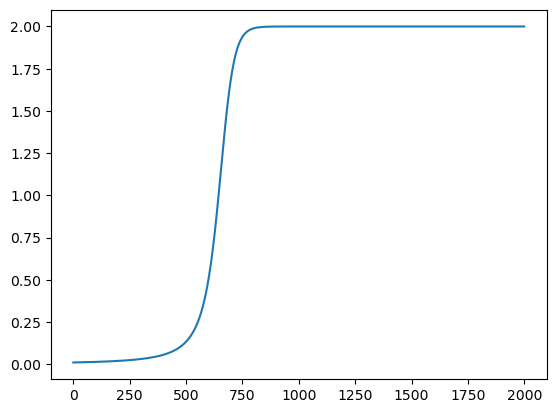

In [4]:
ts, ys = solve(0.05, 2.0, 0.35321)
plt.plot(ts, ys)

In [5]:
def time_to_percent(alpha, p0, a, percent=0.99):
    try:
        ts, ys = solve(alpha, p0, a)
        return ts[np.where(ys >= p0 * percent)[0][0]]
    except IndexError:
        return np.inf

In [6]:
exponents = np.linspace(0, 1, 31)
times = [time_to_percent(0.05, 2.0, a) for a in exponents]

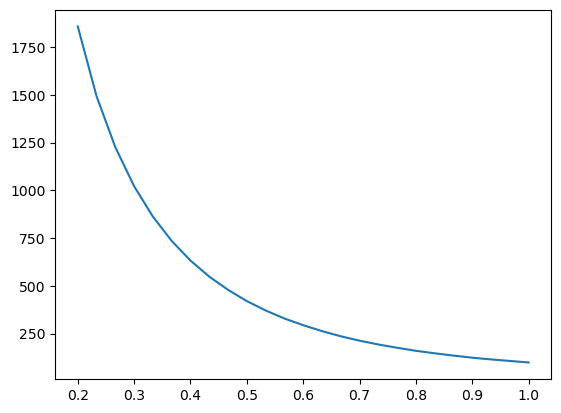

In [7]:
plt.plot(exponents, times)

In [8]:
p0s = np.linspace(0, 1, 31)
times = [time_to_percent(0.15, p0, 0.33) for p0 in p0s]

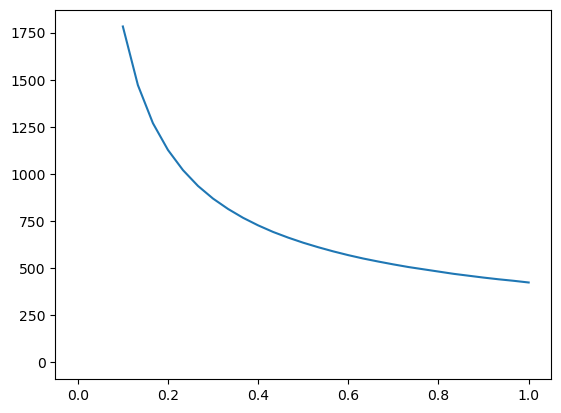

In [12]:
plt.plot(p0s, times)

## Second Equation

$$ \frac{dP}{dt} = \alpha P \left(\beta \left(\frac{C}{P}\right) - P\right)$$
$$ \frac{dC}{dt} = \gamma C P^a$$

In [81]:
ode_rhs = lambda alpha, beta, gamma, a : lambda t, xs: np.array([
    alpha * xs[0] * (beta * xs[1] - xs[0]),
    gamma * xs[1] * xs[0] ** a
])

In [82]:
def solve_euler(dydt, initial_value=np.array([0.01, 0.01]), final_time=100, num_steps=1001):
    ts = np.linspace(0, final_time, num_steps)
    dt = final_time/num_steps
    ys = np.zeros((num_steps, initial_value.shape[0]))
    ys[0, :] = initial_value
    for k, t in enumerate(tqdm.tqdm(ts[:-1])):
        ys[k+1] = ys[k] + dydt(t, ys[k]) * dt
    return ts, ys

In [83]:
ts, ys = solve_euler(ode_rhs(0.5, 1, 0.4, 0.01), num_steps=100001)

  0%|          | 0/100000 [00:00<?, ?it/s]

/var/folders/s6/w2v5p3l12nv4jz0cy2bqmqq00000gn/T/ipykernel_6859/218980257.py:3: RuntimeWarning: invalid value encountered in double_scalars
  gamma * xs[1] * xs[0] ** a


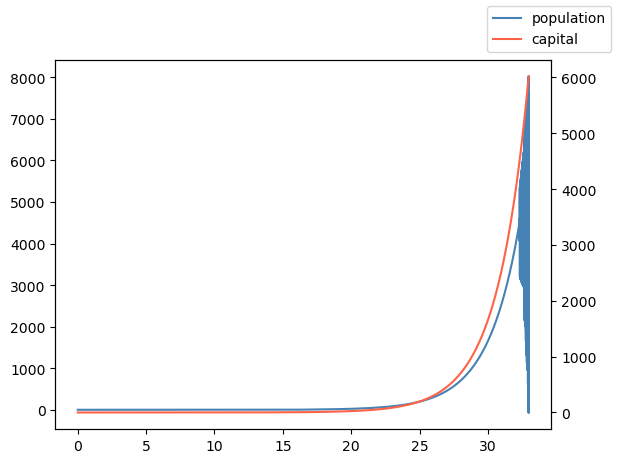

In [84]:
fig, ax = plt.subplots()
tax = ax.twinx()
ax.plot(ts, ys[:, 0], color="steelblue", label="population")
tax.plot(ts, ys[:, 1], color="tomato", label="capital")
fig.legend()